# Sure Tomorrow Insurance Company Project

The Sure Tomorrow insurance company wants to solve several tasks with the help of Machine Learning, and in this project I evaluate that possibility. To do this, I perform 4 tasks:

- Task 1: Find customers who are similar to a given customer. This will help the company's agents with marketing.
- Task 2: Predict whether a new customer is likely to receive an insurance benefit. Can a prediction model do better than a dummy model?
- Task 3: Predict the number of insurance benefits a new customer is likely to receive using a linear regression model.
- Task 4: Protect clients' personal data without breaking the model from the previous task. It's necessary to develop a data transformation algorithm that would make it hard to recover personal information if the data fell into the wrong hands. This is called data masking, or data obfuscation. But the data should be protected in such a way that the quality of machine learning models doesn't suffer. I don't need to pick the best model, just prove that the algorithm works correctly.

# Data Preprocessing & Exploration

## Initialization

In [66]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier
import math
from sklearn.preprocessing import MaxAbsScaler

from sklearn.model_selection import train_test_split

from IPython.display import display

## Load Data

I start by loading data and conducting a basic check that it's free from obvious issues.

In [67]:
df = pd.read_csv('/datasets/insurance_us.csv')

We rename the colums to make the code look more consistent with its style.

In [68]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [69]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
501,0,37.0,59600.0,2,0
2764,0,26.0,24500.0,0,0
1291,0,35.0,46600.0,0,0
2295,0,28.0,41300.0,0,0
4603,1,39.0,54600.0,1,0
3539,0,19.0,36700.0,0,0
602,1,27.0,24400.0,0,0
591,0,30.0,50300.0,0,0
2471,0,25.0,66300.0,1,0
2121,1,36.0,27800.0,2,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


There are no missing values, but `age` should probably be an integer datatype.

In [71]:
# fix the age type (from float to int)
df['age'] = df['age'].astype(int)

In [72]:
# check to see that the conversion was successful
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [73]:
# Have a look at the data's descriptive statistics. 
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


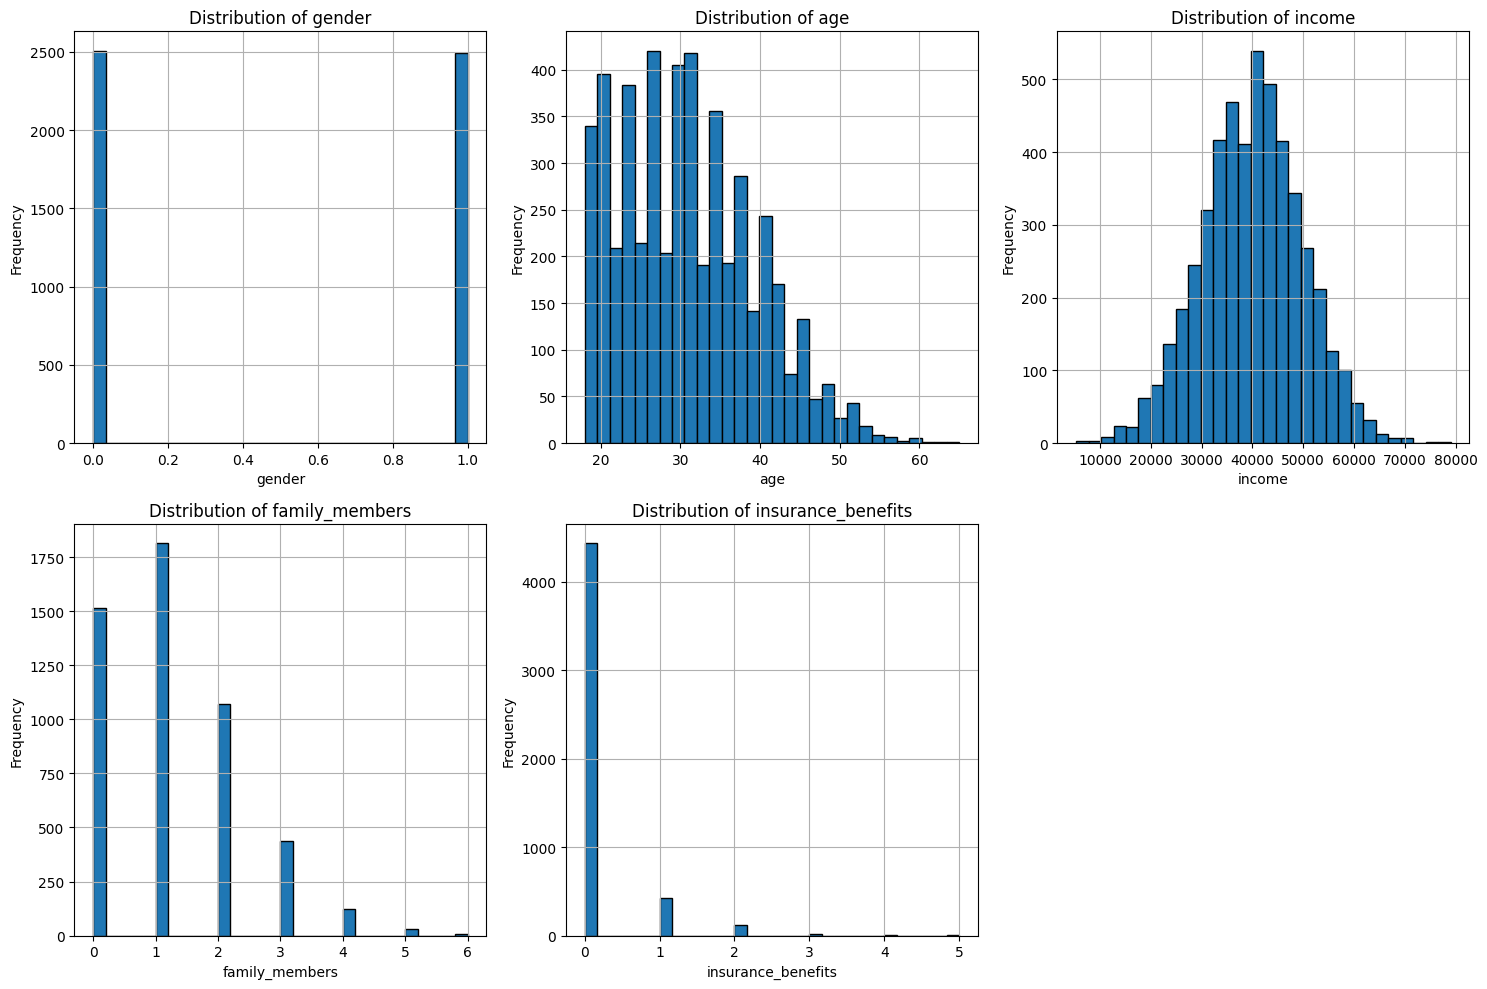

In [74]:
# Plot histograms to visualize distributions

# List variables (columns) to plot
columns = ['gender', 'age', 'income', 'family_members', 'insurance_benefits']

# Create subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i) 
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Gender is binary and evenly split, which is great. Age, family members, and insurance benefits are right-skewed, and income is normally distributed. Nothing looks out of the ordinary here.

Now we can move into analyzing the data further.

## EDA

Let's quickly check whether there are certain groups of customers by looking at the pair plot.

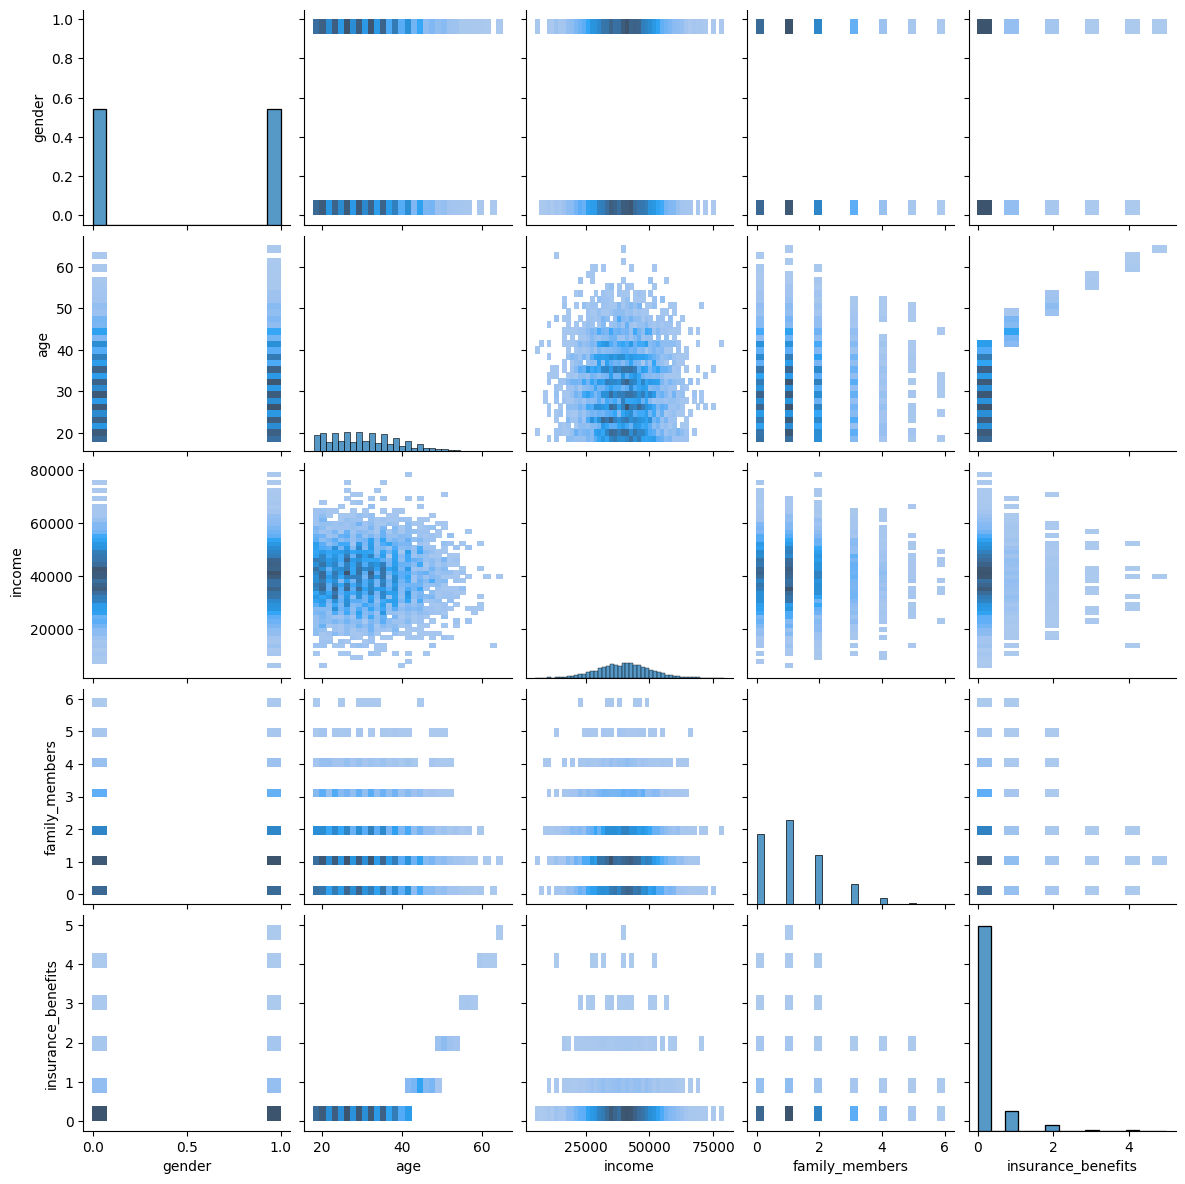

In [75]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

# Task 1. Similar Customers

In the language of ML, it is necessary to develop a procedure that returns k nearest neighbors (objects) for a given object based on the distance between the objects.

To solve the task, we can try different distance metrics.

I write a function that returns k nearest neighbors for an $n^{th}$ object based on a specified distance metric. The number of received insurance benefits is not taken into account for this task. 

Then, I test the function for four combination of two cases:
- Scaling
  - the data is not scaled
  - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler
- Distance Metrics
  - Euclidean
  - Manhattan


In [76]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [77]:
def get_knn(df, n, k, metric):
    
    """
    Returns k nearest neighbors

    :param df: pandas DataFrame used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """

    nbrs = NearestNeighbors(n_neighbors=k, metric=metric).fit(df[feature_names].to_numpy())
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

Scaling the data.

In [78]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [79]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
4651,0.0,0.430769,0.421519,0.333333,0
2908,0.0,0.307692,0.524051,0.166667,0
4401,0.0,0.630769,0.215190,0.166667,0
4530,0.0,0.584615,0.569620,0.166667,0
686,1.0,0.384615,0.510127,0.333333,0


Now, let's get similar records for a given one for every combination. We'll define insurance member 710 as our object and return 5 nearest neighbors.

In [80]:
# Not scaled, Euclidean
nse = get_knn(df[feature_names], 710, 5, metric='euclidean')
print("Not scaled, Euclidean:\n", nse)

Not scaled, Euclidean:
       gender  age   income  family_members  distance
710        0   28  39100.0               2  0.000000
2577       0   26  39100.0               1  2.236068
4194       1   26  39100.0               2  2.236068
564        0   30  39100.0               0  2.828427
4936       1   30  39100.0               0  3.000000


In [81]:
# Not scaled, Manhattan
nsm = get_knn(df[feature_names], 710, 5, metric='manhattan')
print("Not scaled, Manhattan:\n", nsm)

Not scaled, Manhattan:
       gender  age   income  family_members  distance
710        0   28  39100.0               2       0.0
4194       1   26  39100.0               2       3.0
2577       0   26  39100.0               1       3.0
2521       0   25  39100.0               1       4.0
564        0   30  39100.0               0       4.0


In [82]:
# Scaled, Euclidean
se = get_knn(df_scaled[feature_names], 710, 5, metric='euclidean')
print("Scaled, Euclidean:\n", se)

Scaled, Euclidean:
       gender       age    income  family_members  distance
710      0.0  0.430769  0.494937        0.333333  0.000000
1960     0.0  0.430769  0.497468        0.333333  0.002532
2079     0.0  0.446154  0.500000        0.333333  0.016196
1357     0.0  0.446154  0.488608        0.333333  0.016636
259      0.0  0.446154  0.486076        0.333333  0.017754


In [83]:
# Scaled, Manhattan
sm = get_knn(df_scaled[feature_names], 710, 5, metric='manhattan')
print("Scaled, Manhattan:\n", sm)

Scaled, Manhattan:
       gender       age    income  family_members  distance
710      0.0  0.430769  0.494937        0.333333  0.000000
1960     0.0  0.430769  0.497468        0.333333  0.002532
2079     0.0  0.446154  0.500000        0.333333  0.020448
1357     0.0  0.446154  0.488608        0.333333  0.021714
259      0.0  0.446154  0.486076        0.333333  0.024245


**Does the data being not scaled affect the kNN algorithm? If so, how does that appear?** 

Yes, when the data is not scaled, `income` is prioritized more than the other features, and the only neighbors returned are those with the same income.

**How similar are the results using the Manhattan distance metric (regardless of the scaling)?** 

The results using the Manhattan distance metric are very similar to that of the Euclidean distance metric, suggesting that the metric used won't have much of an impact on which neighbors are returned.

# Task 2. Is Customer Likely to Receive Insurance Benefit?

In terms of machine learning we can look at this like a binary classification task.

With `insurance_benefits` being more than zero as the target, I evaluate whether the kNN classification approach can do better than a dummy model.

To do this, I:
- Build a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. This is because it's interesting to see how k may influence the evaluation metric, and whether scaling the data makes any difference. 
- Build the dummy model which is just random for this case. It should return "1" with some probability. I'll test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1.

The probability of paying any insurance benefit can be defined as

$$
P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.
$$

I split the whole data in the 70:30 proportion for the training/testing parts.

In [84]:
# calculate the target

df['insurance_benefits_received'] = df['insurance_benefits'] > 0

In [85]:
# check for the class imbalance with value_counts()

df['insurance_benefits_received'].value_counts()

False    4436
True      564
Name: insurance_benefits_received, dtype: int64

There is a class imbalance, so we'll need to stratify when splitting into training and test sets.

In [86]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# if you have an issue with the following line, restart the kernel and run the notebook again
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)

In [87]:
# generating output of a random model

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [88]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'The probability: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, len(df)) 
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

The probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

The probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

The probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



In [89]:
# Split data into training and test sets 

features_train, features_test, target_train, target_test = train_test_split(df[feature_names],df['insurance_benefits_received'],test_size=.3,stratify=df['insurance_benefits_received'],random_state=1234)

# Fit scaler on training data
scaler = sklearn.preprocessing.MaxAbsScaler().fit(features_train)

# Scale features
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)


In [90]:
# Build KNN classifier, train, and evaluate on unscaled data

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(features_train, target_train)
    predictions = knn.predict(features_test)
    f1 = sklearn.metrics.f1_score(target_test, predictions)
    print('For neighbor k={}'.format(k))
    eval_classifier(target_test, predictions)
    print()

For neighbor k=1
F1: 0.59
Confusion Matrix
[[0.86733333 0.02      ]
 [0.05733333 0.05533333]]

For neighbor k=2
F1: 0.38
Confusion Matrix
[[0.88466667 0.00266667]
 [0.086      0.02666667]]

For neighbor k=3
F1: 0.42
Confusion Matrix
[[0.878      0.00933333]
 [0.08066667 0.032     ]]

For neighbor k=4
F1: 0.19
Confusion Matrix
[[0.88533333 0.002     ]
 [0.10066667 0.012     ]]

For neighbor k=5
F1: 0.21
Confusion Matrix
[[0.882      0.00533333]
 [0.09866667 0.014     ]]

For neighbor k=6
F1: 0.09
Confusion Matrix
[[8.86666667e-01 6.66666667e-04]
 [1.07333333e-01 5.33333333e-03]]

For neighbor k=7
F1: 0.10
Confusion Matrix
[[0.88466667 0.00266667]
 [0.10666667 0.006     ]]

For neighbor k=8
F1: 0.05
Confusion Matrix
[[8.86666667e-01 6.66666667e-04]
 [1.10000000e-01 2.66666667e-03]]

For neighbor k=9
F1: 0.05
Confusion Matrix
[[8.86666667e-01 6.66666667e-04]
 [1.10000000e-01 2.66666667e-03]]

For neighbor k=10
F1: 0.02
Confusion Matrix
[[8.86666667e-01 6.66666667e-04]
 [1.11333333e-01 1.3

In [91]:
# Train and evaluate KNN classifier on scaled data

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(features_train_scaled, target_train)
    predictions = knn.predict(features_test_scaled)
    f1 = sklearn.metrics.f1_score(target_test, predictions)
    print('For neighbor k={}'.format(k))
    eval_classifier(target_test, predictions)
    print()

For neighbor k=1
F1: 0.96
Confusion Matrix
[[0.882      0.00533333]
 [0.004      0.10866667]]

For neighbor k=2
F1: 0.93
Confusion Matrix
[[8.86666667e-01 6.66666667e-04]
 [1.46666667e-02 9.80000000e-02]]

For neighbor k=3
F1: 0.92
Confusion Matrix
[[0.88066667 0.00666667]
 [0.01       0.10266667]]

For neighbor k=4
F1: 0.90
Confusion Matrix
[[0.88533333 0.002     ]
 [0.018      0.09466667]]

For neighbor k=5
F1: 0.91
Confusion Matrix
[[0.882      0.00533333]
 [0.014      0.09866667]]

For neighbor k=6
F1: 0.92
Confusion Matrix
[[0.88533333 0.002     ]
 [0.01466667 0.098     ]]

For neighbor k=7
F1: 0.92
Confusion Matrix
[[0.88333333 0.004     ]
 [0.01266667 0.1       ]]

For neighbor k=8
F1: 0.90
Confusion Matrix
[[0.88533333 0.002     ]
 [0.01866667 0.094     ]]

For neighbor k=9
F1: 0.92
Confusion Matrix
[[0.88466667 0.00266667]
 [0.01533333 0.09733333]]

For neighbor k=10
F1: 0.89
Confusion Matrix
[[0.886      0.00133333]
 [0.02133333 0.09133333]]



Using the scaled data appears to make a significant difference. The model returns high F1 scores when trained on scaled data, and the F1 scores decrease only a small amount as k increases. For unscaled data, the F1 scores overall are lower than for scaled data, and get significantly lower as k increases. This shows that using the scaled data produces a much stronger model to redict whether customers will receive any insurance benefit.

# Task 3. Regression (with Linear Regression)

With `insurance_benefits` as the target, I evaluate what RMSE would be for a Linear Regression model.

First, I build my own implementation of LR. For that, I recall how the linear regression task's solution is formulated in terms of LA. Then, I check RMSE for both the original data and the scaled one and see if there is any difference in RMSE between these two cases.

We denote:
- $X$ — feature matrix, each row is a case, each column is a feature, the first column consists of unities
- $y$ — target (a vector)
- $\hat{y}$ — estimated tagret (a vector)
- $w$ — weight vector

The task of linear regression in the language of matrices can be formulated as:

$$
y = Xw
$$

The training objective then is to find such $w$ that it would minimize the L2-distance (MSE) between $Xw$ and $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

It appears that there is analytical solution for the above:

$$
w = (X^T X)^{-1} X^T y
$$

The formula above can be used to find the weights $w$ and the latter can be used to calculate predicted values

$$
\hat{y} = X_{val}w
$$

I'll split the whole data in the 70:30 proportion for the training/validation parts and use the RMSE metric for the model evaluation.

In [92]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y

    def predict(self, X):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2 @ self.weights
        
        return y_pred

In [93]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

In [94]:
# Check RMSE for unscaled data
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.66


In [95]:
# Check RMSE for scaled data
X_scaled = df_scaled[['age', 'gender', 'income', 'family_members']].to_numpy()
y_scaled = df_scaled['insurance_benefits'].to_numpy()

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train_scaled, y_train_scaled)
print(lr.weights)

y_test_pred = lr.predict(X_test_scaled)
eval_regressor(y_test_scaled, y_test_pred)

[-0.94353901  2.32372069  0.01642727 -0.02059875 -0.07014128]
RMSE: 0.34
R2: 0.66


The RMSE and R2 scores are identical for both the unscaled and scaled data. Scaling the data therefore doesn't seem to impact the error rate of the linear regression model. 

# Task 4. Obfuscating Data

It best to obfuscate data by multiplying the numerical features ( they can be seen as the matrix $X$) by an invertible matrix $P$. 

$$
X' = X \times P
$$

I'll do that and check what the features' values will look like after the transformation. The intertible property is important here so I make sure that $P$ is indeed invertible.

In [96]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [97]:
X = df_pn.to_numpy()

Generating a random matrix $P$.

In [98]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Checking the matrix $P$ is invertible.


In [99]:
# Calculate the determinant of matrix P
det = np.linalg.det(P)
# Matrix P is invertible as long as the determinant does not equal 0
if det == 0:
    print('Matrix P is not invertible.')
else:
    print('Matrix P is invertible.')

Matrix P is invertible.


In [100]:
# Multiply matrix X by invertible matrix P
np.dot(X, P)

array([[ 6359.71527314, 22380.40467609, 18424.09074184, 46000.69669016],
       [ 4873.29406479, 17160.36702982, 14125.78076133, 35253.45577301],
       [ 2693.11742928,  9486.397744  ,  7808.83156024, 19484.86063067],
       ...,
       [ 4346.2234249 , 15289.24126492, 12586.16264392, 31433.50888552],
       [ 4194.09324155, 14751.9910242 , 12144.02930637, 30323.88763426],
       [ 5205.46827354, 18314.24814446, 15077.01370762, 37649.59295455]])

Can you guess the customers' ages or income after the transformation?

No, after the transformation the personal information can't be retrieved without knowing the values of matrix P.

Can you recover the original data from $X'$ if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.

We can calculate the original data from $X'$ if we multiply $X'$ by the inverse of $P$:

$$ X^{'}P^{-1} = X$$

In [101]:
# Save transformed X to variable
X_trans = np.dot(X, P)

# Multiply transformed X by inverse of matrix P
X_reversed = np.dot(X_trans, np.linalg.inv(P))

Print all three cases for a few customers
- The original data
- The transformed one
- The reversed (recovered) one

In [102]:
print("Original data:")
print(X[:5])
print("\nTransformed data:")
print(X_trans[:5])
print("\nRecovered data:")
print(X_reversed[:5])

Original data:
[[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 [0.00e+00 2.10e+01 4.17e+04 2.00e+00]
 [1.00e+00 2.80e+01 2.61e+04 0.00e+00]]

Transformed data:
[[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
 [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]]

Recovered data:
[[ 1.00000000e+00  4.10000000e+01  4.96000000e+04  1.00000000e+00]
 [ 1.67952800e-12  4.60000000e+01  3.80000000e+04  1.00000000e+00]
 [-6.23021448e-13  2.90000000e+01  2.10000000e+04 -2.03032656e-13]
 [-1.08907770e-12  2.10000000e+01  4.17000000e+04  2.00000000e+00]
 [ 1.00000000e+00  2.80000000e+01  2.61000000e+04 -1.52424205e-12]]


You can probably see that some values are not exactly the same as they are in the original data. What might be the reason for that?

The above shows that the data can be recovered using the inverse of matrix P. The values are slightly different, which could be explained by rounding errors, which can compound with each operation. However, these differences are neglible.

## Proof That Data Obfuscation Can Work with LR

The regression task has been solved with linear regression in this project. My next task is to prove _analytically_ that the given obfuscation method won't affect linear regression in terms of predicted values i.e. their values will remain the same.

So, the data is obfuscated and there is $X \times P$ instead of just $X$ now. Consequently, there are other weights $w_P$ as
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

How would $w$ and $w_P$ be linked if you simplify the formula for $w_P$ above? 

What would be predicted values with $w_P$? 

What does that mean for the quality of linear regression if you measure it with RMSE?

**Analytical proof**

Given the below equation: 
    $$w_P = [(XP)^T XP]^{-1} (XP)^T y$$ 
  
Based on reversivity of the transpose of a product of matrices, we have:
    $$w_P = [(XP)^T XP]^{-1} P^{T}X^{T} y$$
    
Then, rearranging the terms inside the square brackets gives us:
    $$w_P = [P^{T}X^{T}XP]^{-1} P^{T}X^{T} y$$
  
Expanding the term inside the square brackets then gives us:
    $$w_P = P^{-1}(X^{T}X)^{-1}(P^{T})^{-1}P^{T}X^{T} y$$

Using multiplicative identity, we know:
    $$(P^{T})^{-1}P^{T} = P^{T}(P^{T})^{-1} = I$$

So, we can reduce the equation down to:
    $$w_P = P^{-1}(X^{T}X)^{-1}IX^{T} y$$

We can see that:
    $$w = (X^{T}X)^{-1}X^{T} y$$
    
So, substituting 'w' in the equation above yields:
    $$w_P = P^{-1}w$$

We know:
    $$y = Xw$$
   
And the prediction of:
    $$y_{P} = X_{P}w_{P}$$
    
So if we replace $w_{P}$ in the above equation, we get:
    $$y_{P} = X_{P}(P^{-1}w)$$

Obsfuscating the input X gives us:
    $$X_{P} = XP$$

If we subsititute this in the above equation, we get:
    $$y_{P} = XPP^{-1}w$$

Then, based on multiplicative identity, we know:
    $$(P^{T})^{-1}P^{T} = P^{T}(P^{T})^{-1} = I$$
    
Therefore, we are left with:
    $$y = y_{P} = Xw$$

The analytical proof shows that the given obfuscation method won't affect linear regression in terms of predicted values. The values will remain the same after obfuscation.

## Test Linear Regression With Data Obfuscation

Now, let's prove Linear Regression can work computationally with the chosen obfuscation transformation.

Here, I build a procedure or a class that runs Linear Regression optionally with the obfuscation. 

I run Linear Regression for the original data and the obfuscated one, and compare the predicted values and the RMSE, $R^2$ metric values to see if there is any difference.

**Procedure**

- Create a square matrix $P$ of random numbers.
- Check that it is invertible. If not, repeat the first point until we get an invertible matrix.
- Run Linear Regression for the original data $X$
- Use $XP$ as the new feature matrix

In [103]:
# Define function to generate a random square matrix 
def generate_square_matrix(num_features, seed=42):
    rng = np.random.default_rng(seed=seed)
    return rng.random(size=(num_features, num_features))

# Create square matrix P
P = generate_square_matrix(4, seed=1234)

In [104]:
# Define function to check that matrix is invertible
def invertible(P):
    return np.allclose(np.dot(P, np.linalg.inv(P)), np.dot(np.linalg.inv(P), P))

# Check if P is invertible
invertible(P)

True

In [105]:
# Run Linear Regression on original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
y_test_pred = lr.predict(X_test)

# Calculate RMSE and R2
eval_regressor(y_test, y_test_pred)

RMSE: 0.34
R2: 0.66


In [106]:
# Create obfuscated matrix XP
X_transformed = np.dot(X, P)

# Run Linear Regression on obfuscated data
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
y_test_pred = lr.predict(X_test)

# Calculate RMSE and R2
eval_regressor(y_test, y_test_pred)

RMSE: 0.34
R2: 0.66


We can see that the RMSE and $R^2$ scores do not change at all after the obfuscation transformation, proving that Linear Regression can work computationally with the chosen obfuscation transformation.

# Conclusions

In this project for Sure Tomorrow Insurance Company, I explored the potential of machine learning to enhance business intelligence and decision-making across four key tasks. Each task addressed a unique use case, from customer segmentation to privacy-preserving prediction, and demonstrated the power and flexibility of applied machine learning.

- Task 1: To assist with targeted marketing, I developed a k-nearest neighbors (kNN) system to find similar customers based on demographic and financial attributes. The analysis revealed that feature scaling significantly improves neighbor identification, preventing high-variance features (like income) from dominating distance metrics. Both Euclidean and Manhattan distances yielded similar results, showing flexibility in metric choice.

- Task 2: I reframed the prediction of insurance benefit receipt as a binary classification problem. Using kNN classifiers, I showed that the model outperformed dummy baselines, especially when trained on scaled data. The best models returned F1 scores well above those of random predictions, confirming the model’s predictive performance. 

- Task 3: To estimate the number of insurance benefits customers will receive, I implemented Linear Regression and compared performance on both scaled and unscaled data. The model produced consistent RMSE and R² values across both versions, demonstrating that scaling had no impact on regression performance in this context.

- Task 4: Finally, I tackled the challenge of data obfuscation to protect clients' personal data. By multiplying the input feature matrix by an invertible matrix $P$, I  masked the original data without compromising model performance. Both analytical proof and computational tests confirmed that linear regression predictions remain unchanged after transformation, validating this method as a viable way to preserve personal customer data.

Based on these tasks, Sure Tomorrow Insurance can now:

* Target similar customers more effectively

* Predict benefit likelihood to manage risk

* Estimate resource needs through benefit count predictions

* Protect sensitive client data while maintaining model quality

These outcomes lay the foundation for more data-driven operations and open the door for future enhancements like model deployment or expanding to more advanced algorithms.